In [30]:
# Only run once; ensures latest compatible versions for Python 3.12
!pip install --quiet torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!pip install --quiet transformers tensorflow keras pandas numpy matplotlib seaborn scikit-learn nltk wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.9/188.9 MB 6.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
peft 0.18.1 requires transformers, which is not installed.
sentence-transformers 5.3.0 requires transformers<6.0.0,>=4.41.0, which is not installed.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 2.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.21.0 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.21.0 which is incompatible.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.21.0 which is incompatible.


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

from wordcloud import WordCloud

# TensorFlow / Keras for LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# PyTorch + Transformers for BERT
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Device: cpu


In [32]:
# Replace paths with your files
import pandas as pd
df_true = pd.read_csv(r'/True.csv')
df_fake = pd.read_csv(r'/Fake.csv')

df_true['label'] = 'REAL'
df_fake['label'] = 'FAKE'

df_true = df_true[['text','label']]
df_fake = df_fake[['text','label']]

# Combine datasets
df = pd.concat([df_true, df_fake], ignore_index=True)
df = df.dropna(subset=['text'])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.head()

,text,label
0,"Donald Trump s White House is in chaos, and th...",FAKE
1,Now that Donald Trump is the presumptive GOP n...,FAKE
2,Mike Pence is a huge homophobe. He supports ex...,FAKE
3,SAN FRANCISCO (Reuters) - California Attorney ...,REAL
4,Twisted reasoning is all that comes from Pelos...,FAKE


In [33]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

df['clean_text'] = df['text'].apply(clean_text)

In [34]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])  # FAKE=1, REAL=0

In [35]:
X = df['clean_text']
y = df['label_enc']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

Logistic Regression Accuracy: 0.9899777282850779
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4669
           1       0.99      0.99      0.99      4311

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



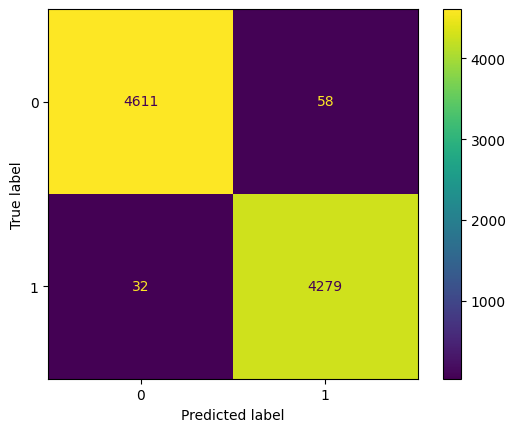

In [37]:
lr = LogisticRegression()
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
ConfusionMatrixDisplay.from_estimator(lr, X_test_tfidf, y_test)
plt.show()

Random Forest Accuracy: 0.9979955456570155
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4669
           1       1.00      1.00      1.00      4311

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



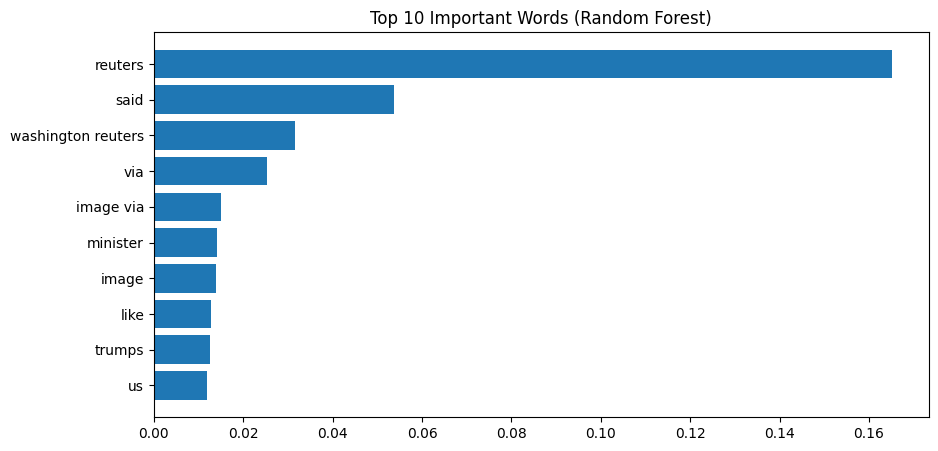

In [38]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_tfidf, y_train)
y_pred_rf = rf.predict(X_test_tfidf)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# Top 10 important words
importances = rf.feature_importances_
indices = np.argsort(importances)[-10:]
features = tfidf.get_feature_names_out()

plt.figure(figsize=(10,5))
plt.barh(range(10), importances[indices], align='center')
plt.yticks(range(10), [features[i] for i in indices])
plt.title("Top 10 Important Words (Random Forest)")
plt.show()

In [39]:
tokenizer_dl = Tokenizer(num_words=5000)
tokenizer_dl.fit_on_texts(X_train)

X_train_seq = tokenizer_dl.texts_to_sequences(X_train)
X_test_seq = tokenizer_dl.texts_to_sequences(X_test)

max_len = 200
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

model_lstm = Sequential([
    Embedding(input_dim=5000, output_dim=128, input_length=max_len),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history_lstm = model_lstm.fit(X_train_pad, y_train, epochs=3, batch_size=64, validation_split=0.1)

score_lstm = model_lstm.evaluate(X_test_pad, y_test)
print("LSTM Test Accuracy:", score_lstm[1])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3
506/506 ━━━━━━━━━━━━━━━━━━━━ 414s 809ms/step - accuracy: 0.9491 - loss: 0.1466 - val_accuracy: 0.9641 - val_loss: 0.1030
Epoch 2/3
506/506 ━━━━━━━━━━━━━━━━━━━━ 348s 688ms/step - accuracy: 0.9744 - loss: 0.0778 - val_accuracy: 0.9864 - val_loss: 0.0452
Epoch 3/3
506/506 ━━━━━━━━━━━━━━━━━━━━ 378s 680ms/step - accuracy: 0.9731 - loss: 0.0800 - val_accuracy: 0.9836 - val_loss: 0.0510
281/281 ━━━━━━━━━━━━━━━━━━━━ 24s 86ms/step - accuracy: 0.9773 - loss: 0.0581
LSTM Test Accuracy: 0.9772828221321106


In [40]:
tokenizer_bert = AutoTokenizer.from_pretrained("bert-base-uncased")
bert_model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=2
).to(device)

def encode_bert(texts, max_len=128):
    return tokenizer_bert(
        list(texts),
        padding='max_length',
        truncation=True,
        max_length=max_len,
        return_tensors='pt'
    ).to(device)

# Sample BERT inference
sample_text = ["Breaking news: Aliens discovered on Mars!"]
inputs = encode_bert(sample_text)
with torch.no_grad():
    outputs = bert_model(**inputs)
pred_label = torch.argmax(outputs.logits, dim=1).item()
print("BERT Prediction:", "Fake" if pred_label==1 else "Real")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT Prediction: Real


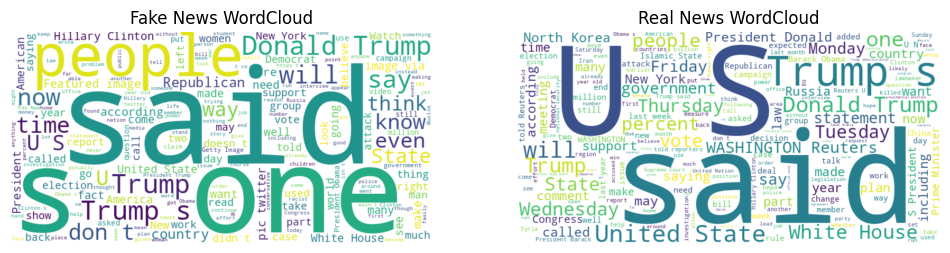

In [41]:
fake = df[df['label']=='FAKE']['text']
real = df[df['label']=='REAL']['text']

wc_fake = WordCloud(width=800, height=400, background_color='white').generate(' '.join(fake))
wc_real = WordCloud(width=800, height=400, background_color='white').generate(' '.join(real))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(wc_fake, interpolation='bilinear')
plt.axis('off')
plt.title("Fake News WordCloud")
plt.subplot(1,2,2)
plt.imshow(wc_real, interpolation='bilinear')
plt.axis('off')
plt.title("Real News WordCloud")
plt.show()